In [137]:
import os
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd

# Complete model

In [138]:


model_dir = "incomplete_21_2026-04-17_10-13-55_f3d9e"


def extract_info_from_intervention_log(model_dir, model_type="scbm"):
    experiment_path = os.path.join("experiments", model_type, "CUB")
    concepts_intervened_list = []
    y_accuracies_list = []
    c_accuracies_list = []




    with open(os.path.join(experiment_path, model_dir, "intervention_log.txt"), "r") as f:
        lines = f.readlines()
        for line in lines:
            if "y_accuracy" and "c_accuracy" and "Intervention on" in line:
                concepts_intervened, y_accuracy, c_accuracy = re.findall(r"Intervention on (\d+) concepts:.*?y_accuracy:\s*([0-9.]+)\s+c_accuracy:\s*([0-9.]+)", line)[0]
                concepts_intervened = int(concepts_intervened)
                y_accuracy = float(y_accuracy) * 100
                c_accuracy = float(c_accuracy) * 100

                concepts_intervened_list.append(concepts_intervened)
                y_accuracies_list.append(y_accuracy)
                c_accuracies_list.append(c_accuracy)
    return concepts_intervened_list, y_accuracies_list, c_accuracies_list


            


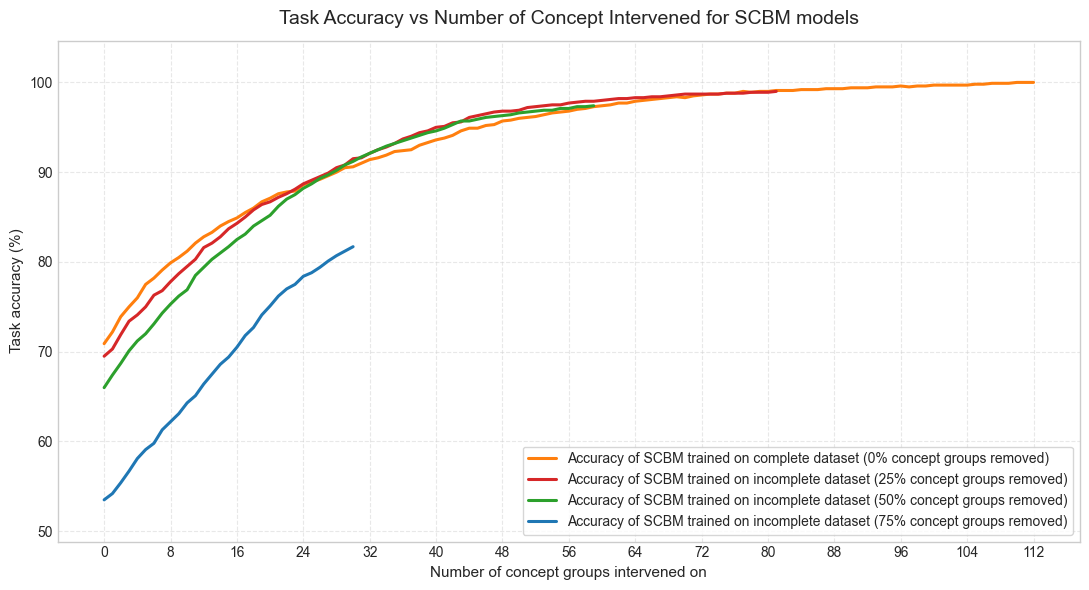

In [139]:
#model_dir_scbm_complete = "complete2026-04-19_13-37-22_fcf0e"
#model_dir_scbm_incomplete_21 = "incomplete_21_2026-04-17_15-40-39_8e524_cluster"
#model_dir_scbm_incomplete_14 = "incomplete_14_2026-04-17_17-54-43_e108f_cluster"
#model_dir_scbm_incomplete_7 = "incomplete_7_2026-04-17_17-54-41_52efd_cluster"

model_dir_scbm_complete = "complete2026-04-19_23-19-06_44b07"
model_dir_scbm_incomplete_7 = "incomplete_7_2026-04-19_23-18-01_c3069"
model_dir_scbm_incomplete_14 = "incomplete_14_2026-04-20_11-38-05_9cc20"
model_dir_scbm_incomplete_21 = "incomplete_21_2026-04-20_11-46-55_b5730"

concepts_intervened_list_scbm_complete, y_accuracies_list_scbm_complete, c_accuracies_list_scbm_complete = extract_info_from_intervention_log(model_dir_scbm_complete)
concepts_intervened_list_scbm_incomplete_21, y_accuracies_list_scbm_incomplete_21, c_accuracies_list_scbm_incomplete_21 = extract_info_from_intervention_log(model_dir_scbm_incomplete_21)
concepts_intervened_list_scbm_incomplete_14, y_accuracies_list_scbm_incomplete_14, c_accuracies_list_scbm_incomplete_14 = extract_info_from_intervention_log(model_dir_scbm_incomplete_14)
concepts_intervened_list_scbm_incomplete_7, y_accuracies_list_scbm_incomplete_7, c_accuracies_list_scbm_incomplete_7 = extract_info_from_intervention_log(model_dir_scbm_incomplete_7)


plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    concepts_intervened_list_scbm_complete,
    y_accuracies_list_scbm_complete,
    linewidth=2.2,
    markersize=6,
    color="#ff7f0e",
    label=r"Accuracy of SCBM trained on complete dataset (0% concept groups removed)",
)

ax.plot(
    concepts_intervened_list_scbm_incomplete_7,
    y_accuracies_list_scbm_incomplete_7,
    color = "#d62728",
    linewidth=2.2,
    markersize=6,
    label=r"Accuracy of SCBM trained on incomplete dataset (25% concept groups removed)",
)

ax.plot(
    concepts_intervened_list_scbm_incomplete_14,
    y_accuracies_list_scbm_incomplete_14,
    color = "#2ca02c",
    linewidth=2.2,
    markersize=6,
    label=r"Accuracy of SCBM trained on incomplete dataset (50% concept groups removed)",
)




ax.plot(
    concepts_intervened_list_scbm_incomplete_21,
    y_accuracies_list_scbm_incomplete_21,
    color = "#1f77b4",
    linewidth=2.2,
    markersize=6,
    label=r"Accuracy of SCBM trained on incomplete dataset (75% concept groups removed)",
)


ax.set_title(
    "Task Accuracy vs Number of Concept Intervened for SCBM models",
    fontsize=14,
    pad=12,
)
ax.set_xlabel("Number of concept groups intervened on", fontsize=11)
ax.set_ylabel("Task accuracy (%)", fontsize=11)

max_len = max(len(concepts_intervened_list_scbm_complete), len(concepts_intervened_list_scbm_incomplete_21), 
              len(concepts_intervened_list_scbm_incomplete_14), len(concepts_intervened_list_scbm_incomplete_7))
ax.xaxis.set_major_locator(MaxNLocator(integer=True, prune=None, nbins=min(20, max_len)))

y_min = min(min(y_accuracies_list_scbm_complete), min(y_accuracies_list_scbm_incomplete_21),
            min(y_accuracies_list_scbm_incomplete_14), min(y_accuracies_list_scbm_incomplete_7))
y_max = max(max(y_accuracies_list_scbm_complete), max(y_accuracies_list_scbm_incomplete_21),
            max(y_accuracies_list_scbm_incomplete_14), max(y_accuracies_list_scbm_incomplete_7))
pad = max((y_max - y_min) * 0.1, 0.5)
ax.set_ylim(y_min - pad, y_max + pad)

ax.grid(True, which="major", linestyle="--", alpha=0.45)
ax.legend(frameon=True)
fig.tight_layout()
plt.show()



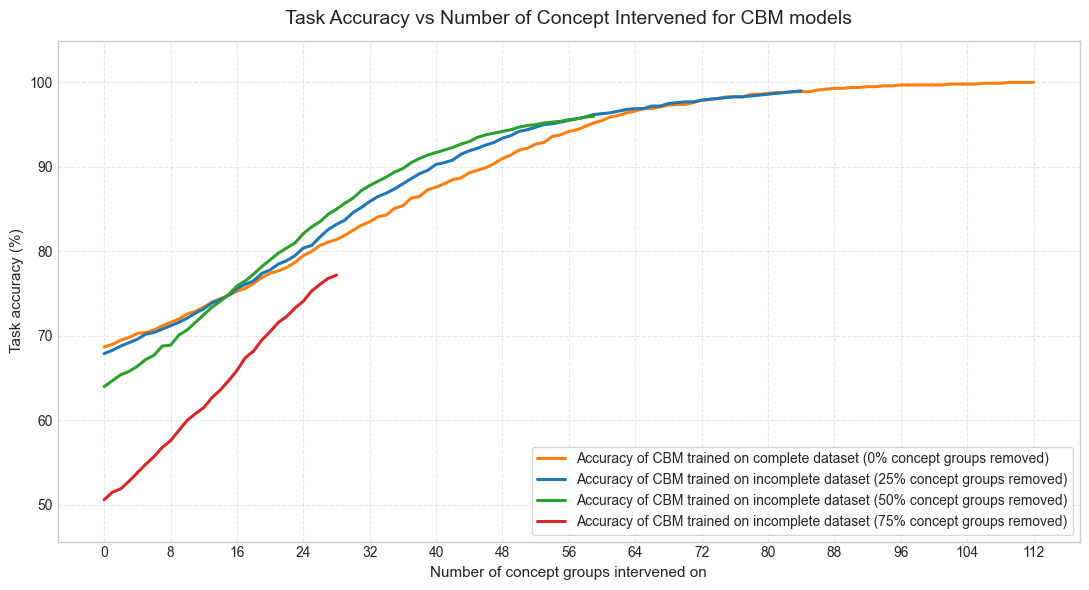

In [140]:



model_dir_cbm_complete = "complete2026-04-18_15-09-53_856ec"
model_dir_cbm_incomplete_7 = "incomplete_7_2026-04-18_13-40-26_065b9"
model_dir_cbm_incomplete_14 = "incomplete_14_2026-04-17_17-19-19_67b49"
model_dir_cbm_incomplete_21 = "incomplete_21_2026-04-18_12-11-55_072f8"

concepts_intervened_list_cbm_complete, y_accuracies_list_cbm_complete, c_accuracies_list_cbm_complete = extract_info_from_intervention_log(model_dir_cbm_complete, model_type="cbm")
concepts_intervened_list_cbm_incomplete_7, y_accuracies_list_cbm_incomplete_7, c_accuracies_list_cbm_incomplete_7 = extract_info_from_intervention_log(model_dir_cbm_incomplete_7, model_type="cbm")
concepts_intervened_list_cbm_incomplete_14, y_accuracies_list_cbm_incomplete_14, c_accuracies_list_cbm_incomplete_14 = extract_info_from_intervention_log(model_dir_cbm_incomplete_14, model_type="cbm")
concepts_intervened_list_cbm_incomplete_21, y_accuracies_list_cbm_incomplete_21, c_accuracies_list_cbm_incomplete_21 = extract_info_from_intervention_log(model_dir_cbm_incomplete_21, model_type="cbm")

len_complete = len(y_accuracies_list_cbm_complete)
len_incomplete_7 = len(y_accuracies_list_cbm_incomplete_7)
len_incomplete_14 = len(y_accuracies_list_cbm_incomplete_14)
len_incomplete_21 = len(y_accuracies_list_cbm_incomplete_21)

concepts_intervened_list_cbm_complete = concepts_intervened_list_cbm_complete[:len_complete//2]
y_accuracies_list_cbm_complete = y_accuracies_list_cbm_complete[:len_complete//2]
concepts_intervened_list_cbm_incomplete_7 = concepts_intervened_list_cbm_incomplete_7[:len_incomplete_7//2]
y_accuracies_list_cbm_incomplete_7 = y_accuracies_list_cbm_incomplete_7[:len_incomplete_7//2]
concepts_intervened_list_cbm_incomplete_14 = concepts_intervened_list_cbm_incomplete_14[:len_incomplete_14//2]
y_accuracies_list_cbm_incomplete_14 = y_accuracies_list_cbm_incomplete_14[:len_incomplete_14//2]
concepts_intervened_list_cbm_incomplete_21 = concepts_intervened_list_cbm_incomplete_21[:len_incomplete_21//2]
y_accuracies_list_cbm_incomplete_21 = y_accuracies_list_cbm_incomplete_21[:len_incomplete_21//2]




plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    concepts_intervened_list_cbm_complete,
    y_accuracies_list_cbm_complete,
    linewidth=2.2,
    markersize=6,
    color="#ff7f0e",
    label=r"Accuracy of CBM trained on complete dataset (0% concept groups removed)",
)   

ax.plot(
    concepts_intervened_list_cbm_incomplete_7,
    y_accuracies_list_cbm_incomplete_7,
    color = "#1f77b4",
    linewidth=2.2,
    markersize=6,
    label=r"Accuracy of CBM trained on incomplete dataset (25% concept groups removed)",
)

ax.plot(
    concepts_intervened_list_cbm_incomplete_14,
    y_accuracies_list_cbm_incomplete_14,
    color = "#2ca02c",
    linewidth=2.2,
    markersize=6,
    label=r"Accuracy of CBM trained on incomplete dataset (50% concept groups removed)",
)   

ax.plot(
    concepts_intervened_list_cbm_incomplete_21,
    y_accuracies_list_cbm_incomplete_21,
    color = "#d62728",
    linewidth=2.2,
    markersize=6,
    label=r"Accuracy of CBM trained on incomplete dataset (75% concept groups removed)",
)

ax.set_title(
    "Task Accuracy vs Number of Concept Intervened for CBM models",
    fontsize=14,
    pad=12,
)
ax.set_xlabel("Number of concept groups intervened on", fontsize=11)
ax.set_ylabel("Task accuracy (%)", fontsize=11) 
max_len = max(len(concepts_intervened_list_cbm_complete), len(concepts_intervened_list_cbm_incomplete_7), len(concepts_intervened_list_cbm_incomplete_14), len(concepts_intervened_list_cbm_incomplete_21))
ax.xaxis.set_major_locator(MaxNLocator(integer=True, prune=None, nbins=min(20, max_len)))

y_min = min(min(y_accuracies_list_cbm_complete), min(y_accuracies_list_cbm_incomplete_7), min(y_accuracies_list_cbm_incomplete_14), min(y_accuracies_list_cbm_incomplete_21))
y_max = max(max(y_accuracies_list_cbm_complete), max(y_accuracies_list_cbm_incomplete_7), max(y_accuracies_list_cbm_incomplete_14), max(y_accuracies_list_cbm_incomplete_21))
pad = max((y_max - y_min) * 0.1, 0.5)
ax.set_ylim(y_min - pad, y_max + pad)
ax.grid(True, which="major", linestyle="--", alpha=0.45)
ax.legend(frameon=True)
fig.tight_layout()

plt.show()
    
    
    

In [141]:
# residual model
res_model = "experiments/scbm_residual/CUB/complete2026-04-20_17-12-36_15d83"
with open(os.path.join(res_model, "log.txt"), "r") as f:
    lines = f.readlines()
    test_line = lines[-1]
    y_accuracy_residual_model, c_accuracy_residual_model = re.findall(r"y_accuracy:\s*([0-9.]+)\s+c_accuracy:\s*([0-9.]+)", test_line)[0]
    y_accuracy_residual_model = float(y_accuracy_residual_model) * 100
    c_accuracy_residual_model = float(c_accuracy_residual_model) * 100


In [142]:
df_dict = {"Models": ["SCBM with residual channel", "SCBM (0% removed)", "SCBM (25% removed)", "SCBM (50% removed)", "SCBM (75% removed)",
                     "CBM (0% removed)", "CBM (25% removed)", "CBM (50% removed)", "CBM (75% removed)"], 
           "Task Accuracy (%)": [y_accuracy_residual_model, y_accuracies_list_scbm_complete[0], y_accuracies_list_scbm_incomplete_7[0], 
                                 y_accuracies_list_scbm_incomplete_14[0], y_accuracies_list_scbm_incomplete_21[0],
                                 y_accuracies_list_cbm_complete[0], y_accuracies_list_cbm_incomplete_7[0],
                                 y_accuracies_list_cbm_incomplete_14[0], y_accuracies_list_cbm_incomplete_21[0]],
           "Concept Accuracy (%)": [c_accuracy_residual_model, c_accuracies_list_scbm_complete[0], c_accuracies_list_scbm_incomplete_7[0],
                                    c_accuracies_list_scbm_incomplete_14[0], c_accuracies_list_scbm_incomplete_21[0],
                                    c_accuracies_list_cbm_complete[0], c_accuracies_list_cbm_incomplete_7[0], 
                                    c_accuracies_list_cbm_incomplete_14[0], c_accuracies_list_cbm_incomplete_21[0]]}


df = pd.DataFrame(df_dict)
df.head(10)

,Models,Task Accuracy (%),Concept Accuracy (%)
0,SCBM with residual channel,70.7,95.2
1,SCBM (0% removed),70.9,95.3
2,SCBM (25% removed),69.5,95.3
3,SCBM (50% removed),66.0,94.8
4,SCBM (75% removed),53.5,94.8
5,CBM (0% removed),68.7,95.2
6,CBM (25% removed),67.9,95.3
7,CBM (50% removed),64.0,95.0
8,CBM (75% removed),50.6,95.0


In [143]:
df_dict = {"Models": ["SCBM (0% removed)", "SCBM (25% removed)", "SCBM (50% removed)", "SCBM (75% removed)",
                     "CBM (0% removed)", "CBM (25% removed)", "CBM (50% removed)", "CBM (75% removed)"], 
           "Task Accuracy (%)": [y_accuracies_list_scbm_complete[-1], y_accuracies_list_scbm_incomplete_7[-1], 
                                 y_accuracies_list_scbm_incomplete_14[-1], y_accuracies_list_scbm_incomplete_21[-1],
                                 y_accuracies_list_cbm_complete[-1], y_accuracies_list_cbm_incomplete_7[-1],
                                 y_accuracies_list_cbm_incomplete_14[-1], y_accuracies_list_cbm_incomplete_21[-1]],
           "Concept Accuracy (%)": [c_accuracies_list_scbm_complete[-1], c_accuracies_list_scbm_incomplete_7[-1],
                                    c_accuracies_list_scbm_incomplete_14[-1], c_accuracies_list_scbm_incomplete_21[-1],
                                    c_accuracies_list_cbm_complete[-1], c_accuracies_list_cbm_incomplete_7[-1], 
                                    c_accuracies_list_cbm_incomplete_14[-1], c_accuracies_list_cbm_incomplete_21[-1]]}


df = pd.DataFrame(df_dict)
df.head(10)

,Models,Task Accuracy (%),Concept Accuracy (%)
0,SCBM (0% removed),100.0,100.0
1,SCBM (25% removed),99.0,100.0
2,SCBM (50% removed),97.4,100.0
3,SCBM (75% removed),81.7,100.0
4,CBM (0% removed),100.0,100.0
5,CBM (25% removed),99.0,100.0
6,CBM (50% removed),96.0,100.0
7,CBM (75% removed),77.2,100.0


# Completeness of datasets

In [148]:
import ast
def retrieve_metrics(dataset_name):
    
    if dataset_name == "class_attr_data_10":
        model = "complete_2026-04-21_11-24-06_33d62"
        model_path = os.path.join("experiments", "linear_head", "CUB", model)
        with open(os.path.join(model_path, "log.txt"), "r") as f:
            lines = f.readlines()
            test_line = lines[-1]
            y_accuracy = re.findall(r"Test Accuracy:\s*([0-9.]+)", test_line)[0]
            y_accuracy = float(y_accuracy) * 100
            return model, y_accuracy
        
    
    for model in os.listdir(os.path.join("experiments", "linear_head", "CUB")):
        if not dataset_name in model:
            continue
        model_path = os.path.join("experiments", "linear_head", "CUB", model)
        with open(os.path.join(model_path, "log.txt"), "r") as f:
            lines = f.readlines()
            test_line = lines[-1]
            y_accuracy = re.findall(r"Test Accuracy:\s*([0-9.]+)", test_line)[0]
            y_accuracy = float(y_accuracy) * 100
            return model, y_accuracy
    return None, None


def get_pkl_dir_from_model_dir(model_dir):
    log_file = os.path.join(model_dir, "log.txt")
    with open(log_file, "r") as f:
        lines = f.readlines()
        info_line = lines[0]
        info_line_dict = ast.literal_eval(info_line)

        pkl_dir = info_line_dict["data"]["pkl_file_dir"]
        return pkl_dir.strip("/")
    
def retrieve_num_attr_groups_removed(pkl_dir):
    log_file = os.path.join("datasets", pkl_dir, "log.txt")
    with open(log_file, "r") as f:
        lines = f.readlines()
        attr_group_line = lines[2]
        #print(attr_group_line)
        num_attr_groups_rmv = re.findall(r"Number of attribute groups removed: (\d+)", attr_group_line)[0]
        return num_attr_groups_rmv


model_types = ["scbm", "cbm"]

df_dict = {"Dataset": [], "Task accuracy on linear c to y model (%)": []}

for model_type in model_types:
    model_dir_path = os.path.join("experiments", model_type, "CUB")
    for model_dir in os.listdir(model_dir_path):
        if "cluster" in model_dir:
            continue
        pkl_dir = get_pkl_dir_from_model_dir(os.path.join(model_dir_path, model_dir))
        #print(model_dir, pkl_dir)
        
        
        if not "incomplete" in model_dir:
            model_name =  f"Dataset used for {model_type.upper()} (0% removed)"
        
        elif "incomplete_7" in model_dir:
            model_name = f"Dataset used for {model_type.upper()} (25% removed)"
            
        elif "incomplete_14" in model_dir:
            model_name = f"Dataset used for {model_type.upper()} (50% removed)"
            
        elif "incomplete_21" in model_dir:
            model_name = f"Dataset used for {model_type.upper()} (75% removed)"
            
    
        if pkl_dir is None:
            print(f"cannot retrieve metrics for model {model_dir} since pkl dir is not found.")
        else:
            model_dir, y_accuracy = retrieve_metrics(pkl_dir)
            
            #print(f"Model: {model_dir}, Test accuracy: {y_accuracy:.2f}%")
            df_dict["Dataset"].append(model_name)
            df_dict["Task accuracy on linear c to y model (%)"].append(y_accuracy)
            
        
    
df_c_to_y = pd.DataFrame(df_dict)
df_sorted = (
    df_c_to_y.assign(
        model=df_c_to_y["Dataset"].str.extract(r'for (\w+)'),
        pct=df_c_to_y["Dataset"].str.extract(r'\((\d+)%').astype(int)
    )
    .sort_values(["model", "pct"], ascending=[False, True])
    .drop(columns=["model", "pct"])
)


df_sorted.head(10)    

,Dataset,Task accuracy on linear c to y model (%)
3,Dataset used for SCBM (0% removed),100.00
0,Dataset used for SCBM (25% removed),100.00
2,Dataset used for SCBM (50% removed),97.93
1,Dataset used for SCBM (75% removed),86.47
7,Dataset used for CBM (0% removed),100.00
6,Dataset used for CBM (25% removed),100.00
5,Dataset used for CBM (50% removed),97.60
4,Dataset used for CBM (75% removed),90.13


In [145]:
print(os.listdir(os.path.join("experiments", "linear_head", "CUB")))

['complete_2026-04-21_11-24-06_33d62', 'class_attr_data_10_incomplete_cluster_10_2026-04-21_14-53-17_eb1b5', 'class_attr_data_10_incomplete_6_cluster_2026-04-21_14-52-10_a16fc', 'class_attr_data_10_incomplete_cluster_9_2026-04-21_14-52-59_80643', 'incomplete_21_2026-04-21_11-36-11_54391', 'class_attr_data_10_incomplete_local_15_2026-04-21_14-53-54_e9e85', 'class_attr_data_10_incomplete_local_14_2026-04-21_14-53-35_7c5b8', 'class_attr_data_10_incomplete_13_2026-04-21_14-52-29_6ad80']


In [149]:
import pickle

data = pickle.load(open("datasets/CUB/incomplete_data/class_attr_data_10_incomplete_cluster_10/train.pkl", "rb"))

print(len(data[0]["attribute_label"]))

30
